# Confusion Matrix Deep Dive

## Objective

Compare multiple machine learning models using confusion matrices.

## Models

- Logistic Regression
- Decision Tree
- KNN

## Concepts

- TP
- FP
- TN
- FN
- Precision
- Recall

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix

In [2]:
df = sns.load_dataset("titanic")

data = df[
    ['pclass','sex','age','fare','survived']
].dropna()

data['sex'] = data['sex'].map({
    'male':0,
    'female':1
})

In [3]:
X = data[
    ['pclass','sex','age','fare']
]

y = data['survived']

In [4]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    title
):
    
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

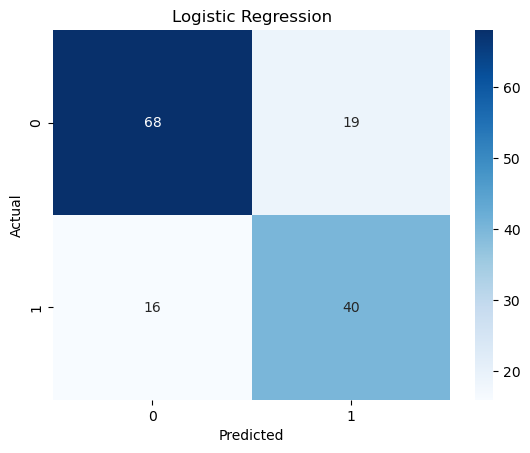

In [6]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

plot_confusion_matrix(
    y_test,
    lr_pred,
    "Logistic Regression"
)

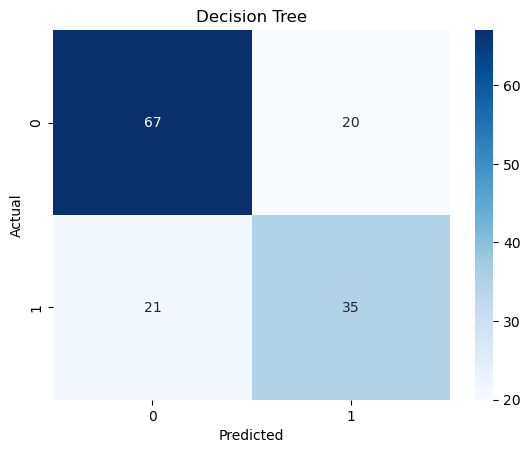

In [7]:
dt = DecisionTreeClassifier()

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

plot_confusion_matrix(
    y_test,
    dt_pred,
    "Decision Tree"
)

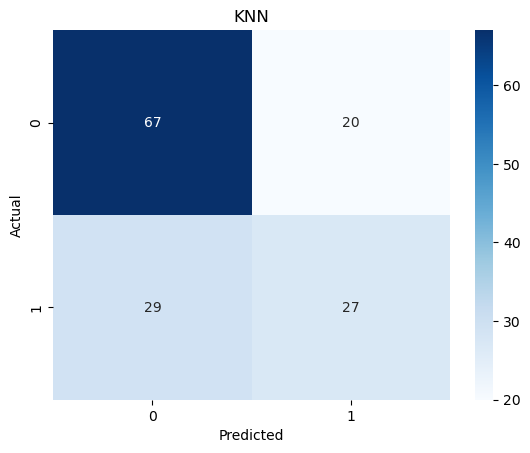

In [8]:
knn = KNeighborsClassifier()

knn.fit(
    X_train,
    y_train
)

knn_pred = knn.predict(
    X_test
)

plot_confusion_matrix(
    y_test,
    knn_pred,
    "KNN"
)

# Precision vs Recall

## Prefer Precision When

- Spam detection
- Fraud detection
- False alarms are expensive

## Prefer Recall When

- Disease detection
- Cancer screening
- Missing a positive case is dangerous

## Key Takeaway

Precision focuses on prediction quality.

Recall focuses on finding all positive cases.